# BERT Fine-tuning (Sentiment Classification of News Headlines)

**BERT** (Bidirectional Encoder Representations from Transformers) is an *encoder-only*
transformer. It reads the whole sequence at once and produces a contextual vector per token —
it does **not** generate text autoregressively the way GPT-2 (decoder-only) or T5
(encoder-decoder) do. That makes it a natural fit for **classification**: we pool BERT's output
and attach a small linear head that predicts a class.

Here we fine-tune `bert-base-uncased` to classify Guardian **Headlines** as *Negative*,
*Neutral*, or *Positive*. The dataset ships without labels, so we derive them by weak
supervision — TextBlob polarity scores bucketed into three classes — then train BERT to
reproduce them.

The pipeline uses the same training refinements as the GPT-2/T5 notebooks: reproducible seeding,
`AdamW` with weight decay, a linear **warmup** LR schedule, gradient clipping, and **early
stopping** that restores the best-performing weights.

> **Before you run this:** switch on the GPU with **Runtime → Change runtime type → Hardware
> accelerator → GPU (T4)**.


In [1]:
# Clone the repo (skips if it already exists)
![ -d /content/Bert-T5-GPT2 ] || git clone https://github.com/nickkats1/Bert-T5-GPT2

Cloning into 'Bert-T5-GPT2'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 75 (delta 17), reused 74 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 3.70 MiB | 38.65 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [2]:
# do this so you can run the code base in colab.
import sys
sys.path.append('/content/Bert-T5-GPT2')

In [3]:
%pip install -q -e /content/Bert-T5-GPT2

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Building editable for bert-t5-gpt2 (pyproject.toml) ... done


## Confirm the GPU is visible
`resolve_device` falls back to CPU if no GPU is found, so this cell is your sanity check that
Colab actually handed you a CUDA device. Fine-tuning BERT on CPU is painfully slow.

In [4]:
import copy
from collections import defaultdict

import torch
from headlines.common import (
    resolve_device, seed_everything, count_parameters, make_generator, EarlyStopping,
)
from headlines.bert.config import CONFIG

seed_everything(CONFIG.seed)          # reproducible splits / shuffling
device = resolve_device(CONFIG.device)
print('Device:', device)
assert device.type == 'cuda', 'No GPU! Enable it via Runtime > Change runtime type.'

Device: cuda


## Load and clean the data
`load_data` reads the Guardian CSV; `clean_data` drops the optional `Time` column, removes rows
missing a `Headlines` value, and de-duplicates.

In [5]:
import pandas as pd
from headlines.bert.utils import load_data, clean_data

df = clean_data(load_data('/content/Bert-T5-GPT2/data/guardian_headlines.csv'))
print(f'{len(df):,} headlines')
df.head(10)

17,795 headlines


,Headlines
0,Johnson is asking Santa for a Christmas recovery
1,‘I now fear the worst’: four grim tales of wor...
2,Five key areas Sunak must tackle to serve up e...
3,Covid-19 leaves firms ‘fatally ill-prepared’ f...
4,The Week in Patriarchy \n\n\n Bacardi's 'lad...
5,English councils call for smoking ban outside ...
6,Can Tesla justify a $300bn valuation?
7,Empty city centres: 'I’m not sure it will ever...
8,Democratising finance for all? An investment a...
9,"Homebuyer loses £300,000 to fraudsters – but g..."


## Derive labels by weak supervision
The dataset has no sentiment labels, so we build them:

1. **`polarity`** — TextBlob scores each headline in `[-1, 1]` (deterministic, no training).
2. **`sentiment`** — bucket the score: `< 0` → *Negative*, `== 0` → *Neutral*, `> 0` → *Positive*.
3. **`label_encode_sentiments`** — map those strings to integers `0/1/2` and drop the helper column.

> These are *weak* labels: BERT can only learn the heuristic's view of sentiment, not ground
> truth. That's fine for a demo of the encoder-classification pipeline.

In [6]:
from headlines.bert.utils import polarity, sentiment, label_encode_sentiments

df['polarity'] = df['Headlines'].apply(polarity)
df['sentiment'] = df['polarity'].apply(sentiment)
df = label_encode_sentiments(df)   # Negative->0, Neutral->1, Positive->2; drops 'polarity'

print(df['sentiment'].value_counts().rename({0: 'Negative', 1: 'Neutral', 2: 'Positive'}))
df.head()

sentiment
Neutral     9867
Positive    4770
Negative    3158
Name: count, dtype: int64


,Headlines,sentiment
0,Johnson is asking Santa for a Christmas recovery,1
1,‘I now fear the worst’: four grim tales of wor...,0
2,Five key areas Sunak must tackle to serve up e...,2
3,Covid-19 leaves firms ‘fatally ill-prepared’ f...,1
4,The Week in Patriarchy \n\n\n Bacardi's 'lad...,0


## Stratified train / val / test split and DataLoaders
`split_train_val_test` carves the data into three **stratified** partitions (so every split
keeps the same class balance — the *Neutral* class dominates here). `create_data_loader`
tokenizes each headline to `max_length=80` and batches it; the training loader is shuffled with a
seeded generator for reproducibility.

In [7]:
from transformers import BertTokenizer
from headlines.bert.utils import split_train_val_test
from headlines.bert.dataset import create_data_loader

tokenizer = BertTokenizer.from_pretrained(CONFIG.model_name)

df_train, df_val, df_test = split_train_val_test(
    df,
    holdout_size=CONFIG.holdout_size,
    test_size_from_holdout=CONFIG.test_size_from_holdout,
    seed=CONFIG.seed,
)
print(f'train={len(df_train):,}  val={len(df_val):,}  test={len(df_test):,}')

train_loader = create_data_loader(
    df_train, tokenizer, CONFIG.max_length, CONFIG.batch_size,
    shuffle=True, generator=make_generator(CONFIG.seed),
)
val_loader = create_data_loader(df_val, tokenizer, CONFIG.max_length, CONFIG.batch_size)
test_loader = create_data_loader(df_test, tokenizer, CONFIG.max_length, CONFIG.batch_size)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

train=8,897  val=7,118  test=1,780


## Load the BERT classifier
`BertClassifier` wraps the pretrained encoder with `Dropout → Linear(hidden_size, num_classes)`.
The head width is read from the encoder config, so swapping in `bert-large-uncased` just works.

In [8]:
from headlines.bert.model import BertClassifier

model = BertClassifier(
    model_name=CONFIG.model_name,
    num_classes=CONFIG.num_classes,
    dropout=CONFIG.dropout,
).to(device)
print(f'Trainable parameters: {count_parameters(model):,}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 109,484,547


## Loss, optimizer, and LR schedule
Cross-entropy over the 3 classes; `AdamW` (decoupled weight decay) over all parameters; and a
**linear warmup** schedule stepped once per batch. Warmup eases the pretrained weights into
fine-tuning instead of shocking them with the full LR immediately.

In [9]:
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

loss_fn = CrossEntropyLoss()
optimizer = AdamW(
    model.parameters(), lr=CONFIG.learning_rate, weight_decay=CONFIG.weight_decay,
)
total_steps = max(1, len(train_loader) * CONFIG.epochs)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(CONFIG.warmup_ratio * total_steps),
    num_training_steps=total_steps,
)

## Fine-tune with early stopping
Each epoch we `train` then `validate`, logging accuracy and loss. `EarlyStopping` (mode `'max'`)
watches **validation accuracy**: we checkpoint the weights whenever it improves and stop once it
fails to improve for `patience` epochs — so we keep the best model, not the last (possibly
overfit) one. After training we run the held-out **test** set once.

In [10]:
from headlines.bert.trainer import train, validate

history = defaultdict(list)
early_stopping = EarlyStopping(patience=CONFIG.patience, mode='max')
best_state = None

for epoch in range(CONFIG.epochs):
    train_acc, train_loss = train(
        model, train_loader, optimizer, device,
        loss_fn=loss_fn, n_examples=len(df_train), scheduler=scheduler,
    )
    val_acc, val_loss = validate(
        model, val_loader, device, loss_fn=loss_fn, n_examples=len(df_val),
    )
    print(f'Epoch {epoch + 1}/{CONFIG.epochs} | '
          f'train acc {train_acc:.4f} loss {train_loss:.4f} | '
          f'val acc {val_acc:.4f} loss {val_loss:.4f}')

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)

    if early_stopping.step(val_acc):
        best_state = copy.deepcopy(model.state_dict())
    if early_stopping.should_stop:
        print(f'Early stopping (best val acc {early_stopping.best:.4f})')
        break

if best_state is not None:
    model.load_state_dict(best_state)  # restore best weights

test_acc, test_loss = validate(
    model, test_loader, device, loss_fn=loss_fn, n_examples=len(df_test),
)
print(f'\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:900.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/4 | train acc 0.6692 loss 0.7838 | val acc 0.8750 loss 0.3785
Epoch 2/4 | train acc 0.9205 loss 0.2834 | val acc 0.9326 loss 0.2698
Epoch 3/4 | train acc 0.9636 loss 0.1599 | val acc 0.9397 loss 0.2838
Epoch 4/4 | train acc 0.9790 loss 0.1004 | val acc 0.9413 loss 0.3074

Test Accuracy: 0.9483 | Test Loss: 0.2557


## Learning curves
Plot train vs. validation accuracy and loss. If validation loss starts climbing while train loss
keeps falling, the model is overfitting — which is exactly what early stopping guards against.

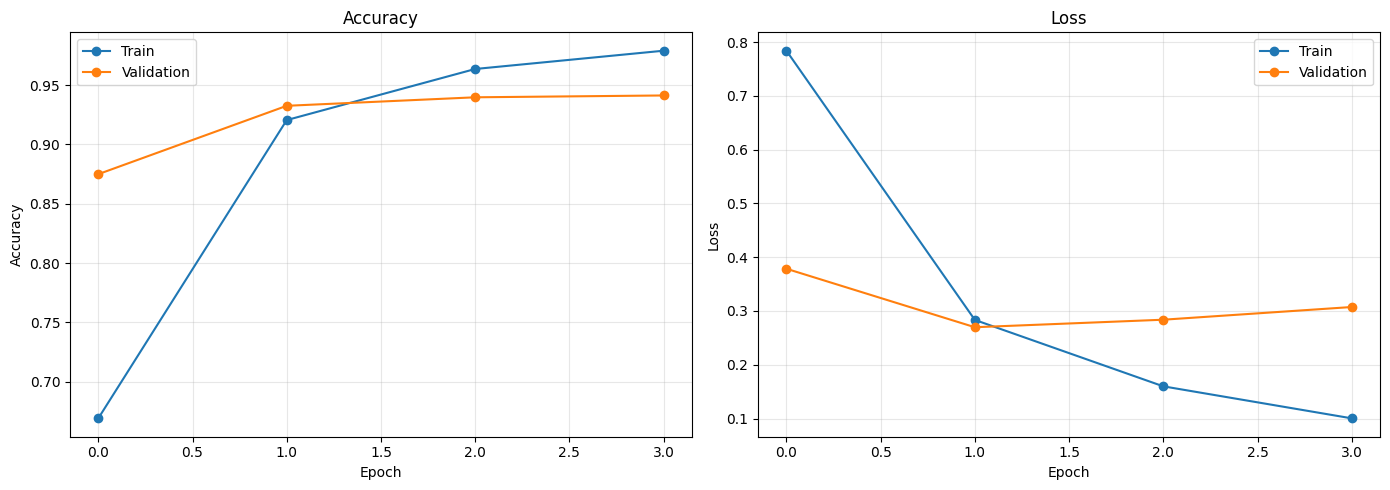

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_acc'], marker='o', label='Train')
ax1.plot(history['val_acc'], marker='o', label='Validation')
ax1.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_loss'], marker='o', label='Train')
ax2.plot(history['val_loss'], marker='o', label='Validation')
ax2.set(xlabel='Epoch', ylabel='Loss', title='Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate on the test set
`get_predictions` runs the (best) model over the test loader and returns predictions and true
labels. `compute_metrics` reports accuracy plus weighted/macro precision/recall/F1 — the macro
scores expose how the rare *Negative*/*Positive* classes do despite *Neutral* dominating.
`classification_summary` prints the full per-class report.

In [12]:
from headlines.bert.metrics import (
    get_predictions, compute_metrics, classification_summary, compute_confusion_matrix,
)
from headlines.bert.utils import CLASS_NAMES

_, y_pred, y_true = get_predictions(model, test_loader, device)
y_pred, y_true = y_pred.tolist(), y_true.tolist()

metrics = compute_metrics(y_true, y_pred)
print({k: round(v, 4) for k, v in metrics.items()})
print()
print(classification_summary(y_true, y_pred, target_names=CLASS_NAMES))

{'accuracy': 0.9483, 'precision_weighted': 0.9488, 'recall_weighted': 0.9483, 'f1_weighted': 0.9485, 'precision_macro': 0.933, 'recall_macro': 0.9384, 'f1_macro': 0.9356}

              precision    recall  f1-score   support

    Negative       0.88      0.91      0.90       316
     Neutral       0.97      0.96      0.97       987
    Positive       0.94      0.94      0.94       477

    accuracy                           0.95      1780
   macro avg       0.93      0.94      0.94      1780
weighted avg       0.95      0.95      0.95      1780



### Confusion matrix
The diagonal is correct predictions. Pinning `labels` to the full class set keeps the matrix
3×3 even if a class is absent from the test split.

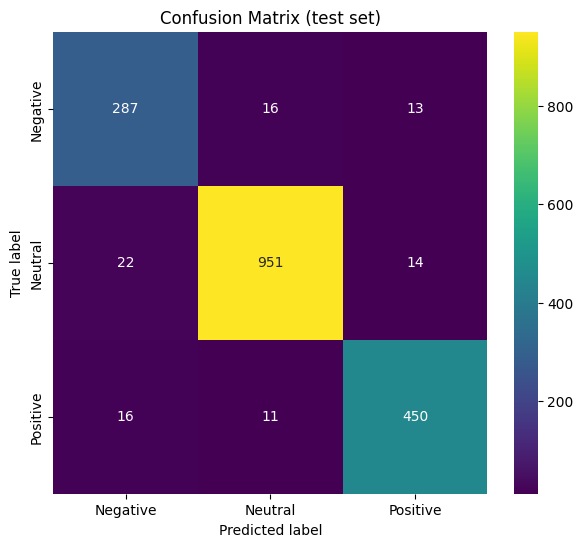

In [13]:
import seaborn as sns

cm = compute_confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, cmap='viridis', annot=True, fmt='d',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (test set)')
plt.show()